In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import time
import copy
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Dirichlet

warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_MODEL_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

with open(f"{CONFIGS_DIR}/feature_columns.json", "r") as f:
    feature_cfg = json.load(f)

ASSETS = master_cfg["assets"]
LOOKBACK = master_cfg["lookback"]
SEED = master_cfg["seed"]
FEATURE_COLS = feature_cfg["feature_columns"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRANSACTION_COST = 0.001

# Transformer config
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 2
FF_DIM = 256
DROPOUT = 0.1

# PPO / training config
LR = 3e-4
WEIGHT_DECAY = 1e-5

GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS = 0.2
VALUE_COEF = 0.5
ENTROPY_COEF = 0.001
MAX_GRAD_NORM = 0.5

TRAIN_EPOCHS = 60
PPO_UPDATES_PER_EPOCH = 10
MINIBATCH_SIZE = 128

DIRICHLET_CONC_MIN = 5.0
DIRICHLET_CONC_MAX = 200.0

RUN_NAME = "transformer_ppo_final_5y"
MODEL_DIR = f"{OUTPUTS_MODEL_DIR}/{RUN_NAME}"
os.makedirs(MODEL_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)
print("ASSETS:", ASSETS)
print("LOOKBACK:", LOOKBACK)
print("N_FEATURES:", len(FEATURE_COLS))
print("MODEL_DIR:", MODEL_DIR)

DEVICE: cpu
ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
LOOKBACK: 20
N_FEATURES: 13
MODEL_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y


In [ ]:
# ============================================================
# CELL 04 — Load env-ready data
# ============================================================

env_ready = np.load(f"{DATA_PROCESSED_DIR}/env_ready_5y.npz", allow_pickle=True)

X_train = env_ready["X_train"].astype(np.float32)
y_train = env_ready["y_train"].astype(np.float32)
dates_train = env_ready["dates_train"]

X_val = env_ready["X_val"].astype(np.float32)
y_val = env_ready["y_val"].astype(np.float32)
dates_val = env_ready["dates_val"]

X_test = env_ready["X_test"].astype(np.float32)
y_test = env_ready["y_test"].astype(np.float32)
dates_test = env_ready["dates_test"]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (717, 20, 5, 13) y_train: (717, 5)
X_val: (250, 20, 5, 13) y_val: (250, 5)
X_test: (251, 20, 5, 13) y_test: (251, 5)


In [ ]:
# ============================================================
# CELL 05 — PortfolioEnv
# ============================================================

@dataclass
class EnvStepResult:
    next_state: Optional[np.ndarray]
    reward: float
    done: bool
    info: Dict


class PortfolioEnv:
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        dates: np.ndarray,
        transaction_cost: float = 0.001,
        reward_mode: str = "cost_aware",
    ):
        assert reward_mode in ["cost_aware", "no_cost"]

        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.dates = dates
        self.transaction_cost = float(transaction_cost)
        self.reward_mode = reward_mode

        self.n_steps = self.X.shape[0]
        self.lookback = self.X.shape[1]
        self.n_assets = self.X.shape[2]
        self.n_features = self.X.shape[3]

        self.reset()

    def reset(self) -> np.ndarray:
        self.t = 0
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_value = 1.0
        self.done = False
        return self.X[self.t]

    def _sanitize_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32).reshape(-1)
        if len(action) != self.n_assets:
            raise ValueError(f"Action length {len(action)} != n_assets {self.n_assets}")

        action = np.clip(action, 1e-8, None)
        action = action / action.sum()
        return action.astype(np.float32)

    def step(self, action: np.ndarray) -> EnvStepResult:
        if self.done:
            raise RuntimeError("Episode already done. Call reset().")

        w_t = self._sanitize_action(action)
        r_t = self.y[self.t]

        portfolio_simple_return = float(np.dot(w_t, r_t))
        turnover = float(np.sum(np.abs(w_t - self.prev_weights)))
        trading_cost = self.transaction_cost * turnover

        portfolio_simple_return = max(portfolio_simple_return, -0.999999)

        reward_no_cost = math.log(1.0 + portfolio_simple_return)
        reward_cost_aware = reward_no_cost - trading_cost
        reward = reward_cost_aware if self.reward_mode == "cost_aware" else reward_no_cost

        gross_value_next = self.portfolio_value * (1.0 + portfolio_simple_return)
        net_value_next = gross_value_next * (1.0 - trading_cost)

        self.portfolio_value = float(net_value_next)
        self.prev_weights = w_t.copy()

        info = {
            "date": str(self.dates[self.t]),
            "weights": w_t.copy(),
            "asset_returns": r_t.copy(),
            "portfolio_simple_return": portfolio_simple_return,
            "reward_no_cost": reward_no_cost,
            "reward_cost_aware": reward_cost_aware,
            "turnover": turnover,
            "trading_cost": trading_cost,
            "portfolio_value": self.portfolio_value,
        }

        self.t += 1
        self.done = (self.t >= self.n_steps)
        next_state = None if self.done else self.X[self.t]

        return EnvStepResult(
            next_state=next_state,
            reward=float(reward),
            done=self.done,
            info=info,
        )

In [ ]:
# ============================================================
# CELL 06 — Transformer actor-critic
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, L, D]
        l = x.size(1)
        return x + self.pe[:, :l, :]


class TransformerEncoderState(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
    ):
        super().__init__()

        self.lookback = lookback
        self.n_assets = n_assets
        self.n_features = n_features
        self.input_dim = n_assets * n_features
        self.d_model = d_model

        self.input_proj = nn.Linear(self.input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=lookback + 5)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers,
        )

        self.post = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, L, N, F]
        b, l, n, f = x.shape
        x = x.reshape(b, l, n * f)   # [B, L, N*F]
        x = self.input_proj(x)       # [B, L, D]
        x = self.pos_encoder(x)      # [B, L, D]
        h = self.transformer(x)      # [B, L, D]

        # use last token representation as latent state
        h_last = h[:, -1, :]         # [B, D]
        h_last = self.post(h_last)
        return h_last


class TransformerActorCritic(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
        conc_min: float = 5.0,
        conc_max: float = 200.0,
    ):
        super().__init__()

        self.n_assets = n_assets
        self.conc_min = conc_min
        self.conc_max = conc_max

        self.encoder = TransformerEncoderState(
            lookback=lookback,
            n_assets=n_assets,
            n_features=n_features,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
        )

        self.actor_logits = nn.Linear(d_model, n_assets)
        self.actor_concentration = nn.Linear(d_model, 1)
        self.critic = nn.Linear(d_model, 1)

    def _get_shared(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def get_policy_dist(self, x: torch.Tensor):
        h = self._get_shared(x)

        logits = self.actor_logits(h)
        mean_weights = torch.softmax(logits, dim=-1)

        raw_conc = self.actor_concentration(h)
        conc_scalar = torch.sigmoid(raw_conc)
        conc_scalar = self.conc_min + (self.conc_max - self.conc_min) * conc_scalar
        conc_scalar = conc_scalar.squeeze(-1)

        alpha = mean_weights * conc_scalar.unsqueeze(-1)
        alpha = torch.clamp(alpha, min=1e-4)

        dist = Dirichlet(alpha)
        return dist, mean_weights, alpha

    def get_value(self, x: torch.Tensor) -> torch.Tensor:
        h = self._get_shared(x)
        v = self.critic(h).squeeze(-1)
        return v

    def act(self, x: torch.Tensor):
        dist, mean_weights, alpha = self.get_policy_dist(x)
        action = dist.rsample()
        log_prob = dist.log_prob(action)
        value = self.get_value(x)
        entropy = dist.entropy()
        return action, log_prob, value, entropy, mean_weights, alpha

    def act_deterministic(self, x: torch.Tensor):
        dist, mean_weights, alpha = self.get_policy_dist(x)
        value = self.get_value(x)
        return mean_weights, value, alpha

In [ ]:
# ============================================================
# CELL 07 — PPO buffer helpers
# ============================================================

def compute_gae(
    rewards: np.ndarray,
    values: np.ndarray,
    dones: np.ndarray,
    gamma: float,
    gae_lambda: float,
):
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    last_adv = 0.0

    for t in reversed(range(T)):
        next_value = 0.0 if t == T - 1 else values[t + 1]
        next_nonterminal = 1.0 - dones[t]

        delta = rewards[t] + gamma * next_value * next_nonterminal - values[t]
        last_adv = delta + gamma * gae_lambda * next_nonterminal * last_adv
        advantages[t] = last_adv

    returns = advantages + values
    return advantages.astype(np.float32), returns.astype(np.float32)


def normalize_advantages(adv: torch.Tensor) -> torch.Tensor:
    return (adv - adv.mean()) / (adv.std() + 1e-8)

In [ ]:
# ============================================================
# CELL 08 — Rollout collection
# ============================================================

def collect_rollout(model: nn.Module, env: PortfolioEnv, device: str):
    model.eval()

    states = []
    actions = []
    log_probs = []
    rewards = []
    dones = []
    values = []
    entropies = []
    infos = []

    state = env.reset()

    while True:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action_t, log_prob_t, value_t, entropy_t, mean_weights_t, alpha_t = model.act(state_tensor)

        action = action_t.squeeze(0).cpu().numpy()
        result = env.step(action)

        states.append(state)
        actions.append(action)
        log_probs.append(float(log_prob_t.item()))
        rewards.append(float(result.reward))
        dones.append(float(result.done))
        values.append(float(value_t.item()))
        entropies.append(float(entropy_t.item()))
        infos.append(result.info)

        if result.done:
            break

        state = result.next_state

    rollout = {
        "states": np.asarray(states, dtype=np.float32),
        "actions": np.asarray(actions, dtype=np.float32),
        "log_probs": np.asarray(log_probs, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=np.float32),
        "values": np.asarray(values, dtype=np.float32),
        "entropies": np.asarray(entropies, dtype=np.float32),
        "infos": infos,
    }

    advantages, returns = compute_gae(
        rewards=rollout["rewards"],
        values=rollout["values"],
        dones=rollout["dones"],
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
    )

    rollout["advantages"] = advantages
    rollout["returns"] = returns
    return rollout

In [ ]:
# ============================================================
# CELL 09 — PPO update
# ============================================================

def ppo_update(model, optimizer, rollout, device: str):
    model.train()

    states = torch.tensor(rollout["states"], dtype=torch.float32, device=device)
    actions = torch.tensor(rollout["actions"], dtype=torch.float32, device=device)
    old_log_probs = torch.tensor(rollout["log_probs"], dtype=torch.float32, device=device)
    returns = torch.tensor(rollout["returns"], dtype=torch.float32, device=device)
    advantages = torch.tensor(rollout["advantages"], dtype=torch.float32, device=device)
    advantages = normalize_advantages(advantages)

    n_samples = states.size(0)
    idxs = np.arange(n_samples)

    update_logs = []

    for _ in range(PPO_UPDATES_PER_EPOCH):
        np.random.shuffle(idxs)

        for start in range(0, n_samples, MINIBATCH_SIZE):
            end = start + MINIBATCH_SIZE
            mb_idx = idxs[start:end]

            mb_states = states[mb_idx]
            mb_actions = actions[mb_idx]
            mb_old_log_probs = old_log_probs[mb_idx]
            mb_returns = returns[mb_idx]
            mb_advantages = advantages[mb_idx]

            dist, mean_weights, alpha = model.get_policy_dist(mb_states)
            new_log_probs = dist.log_prob(mb_actions)
            entropy = dist.entropy().mean()

            values = model.get_value(mb_states)

            ratio = torch.exp(new_log_probs - mb_old_log_probs)

            surr1 = ratio * mb_advantages
            surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * mb_advantages
            actor_loss = -torch.min(surr1, surr2).mean()

            value_loss = ((values - mb_returns) ** 2).mean()

            total_loss = actor_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy

            optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            approx_kl = (mb_old_log_probs - new_log_probs).mean().item()
            clip_frac = ((torch.abs(ratio - 1.0) > CLIP_EPS).float().mean().item())

            update_logs.append({
                "actor_loss": float(actor_loss.item()),
                "value_loss": float(value_loss.item()),
                "entropy": float(entropy.item()),
                "approx_kl": float(approx_kl),
                "clip_frac": float(clip_frac),
            })

    return pd.DataFrame(update_logs)

In [ ]:
# ============================================================
# CELL 10 — Evaluation helpers
# ============================================================

def compute_rollout_metrics(df_rollout: pd.DataFrame) -> Dict:
    ret = df_rollout["portfolio_simple_return"].values
    pv = df_rollout["portfolio_value"].values
    turnover = df_rollout["turnover"].values

    cumulative_return = pv[-1] - 1.0
    avg_daily_return = float(np.mean(ret))
    daily_vol = float(np.std(ret))
    sharpe = float(avg_daily_return / (daily_vol + 1e-12) * np.sqrt(252))

    running_max = np.maximum.accumulate(pv)
    drawdown = pv / (running_max + 1e-12) - 1.0
    max_drawdown = float(np.min(drawdown))

    avg_turnover = float(np.mean(turnover))

    return {
        "n_steps": len(df_rollout),
        "final_portfolio_value": float(pv[-1]),
        "cumulative_return": float(cumulative_return),
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_vol,
        "sharpe_approx": sharpe,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
    }


def evaluate_policy(model, X, y, dates, device: str, reward_mode: str = "cost_aware"):
    model.eval()

    env = PortfolioEnv(
        X=X,
        y=y,
        dates=dates,
        transaction_cost=TRANSACTION_COST,
        reward_mode=reward_mode,
    )

    state = env.reset()
    rows = []

    while True:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action_t, value_t, alpha_t = model.act_deterministic(state_tensor)

        action = action_t.squeeze(0).cpu().numpy()
        result = env.step(action)

        row = {
            "date": result.info["date"],
            "portfolio_simple_return": result.info["portfolio_simple_return"],
            "reward_no_cost": result.info["reward_no_cost"],
            "reward_cost_aware": result.info["reward_cost_aware"],
            "turnover": result.info["turnover"],
            "trading_cost": result.info["trading_cost"],
            "portfolio_value": result.info["portfolio_value"],
        }

        for i, asset in enumerate(ASSETS):
            row[f"w_{asset}"] = float(result.info["weights"][i])

        rows.append(row)

        if result.done:
            break

        state = result.next_state

    df_rollout = pd.DataFrame(rows)
    metrics = compute_rollout_metrics(df_rollout)
    return df_rollout, metrics

In [ ]:
# ============================================================
# CELL 11 — Build model and optimizer
# ============================================================

model = TransformerActorCritic(
    lookback=LOOKBACK,
    n_assets=len(ASSETS),
    n_features=len(FEATURE_COLS),
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    dropout=DROPOUT,
    conc_min=DIRICHLET_CONC_MIN,
    conc_max=DIRICHLET_CONC_MAX,
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

print(model)

TransformerActorCritic(
  (encoder): TransformerEncoderState(
    (input_proj): Linear(in_features=65, out_features=128, bias=True)
    (pos_encoder): PositionalEncoding()
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (post): Sequential(
      (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True

In [ ]:
# ============================================================
# CELL 12 — One dry rollout before training
# ============================================================

train_env = PortfolioEnv(
    X=X_train,
    y=y_train,
    dates=dates_train,
    transaction_cost=TRANSACTION_COST,
    reward_mode="cost_aware",
)

dry_rollout = collect_rollout(model, train_env, DEVICE)

print("dry states:", dry_rollout["states"].shape)
print("dry actions:", dry_rollout["actions"].shape)
print("dry rewards:", dry_rollout["rewards"].shape)
print("dry returns:", dry_rollout["returns"].shape)
print("dry advantages:", dry_rollout["advantages"].shape)

dry states: (717, 20, 5, 13)
dry actions: (717, 5)
dry rewards: (717,)
dry returns: (717,)
dry advantages: (717,)


In [ ]:
# ============================================================
# CELL 13 — Training loop
# ============================================================

history_rows = []

best_val_cumret = -1e18
best_state_dict = None
best_epoch = -1

start_time = time.time()

for epoch in range(1, TRAIN_EPOCHS + 1):
    train_env = PortfolioEnv(
        X=X_train,
        y=y_train,
        dates=dates_train,
        transaction_cost=TRANSACTION_COST,
        reward_mode="cost_aware",
    )

    rollout = collect_rollout(model, train_env, DEVICE)
    update_df = ppo_update(model, optimizer, rollout, DEVICE)

    train_eval_rollout, train_metrics = evaluate_policy(model, X_train, y_train, dates_train, DEVICE)
    val_eval_rollout, val_metrics = evaluate_policy(model, X_val, y_val, dates_val, DEVICE)

    row = {
        "epoch": epoch,
        "train_cumulative_return": train_metrics["cumulative_return"],
        "train_sharpe": train_metrics["sharpe_approx"],
        "train_max_drawdown": train_metrics["max_drawdown"],
        "train_avg_turnover": train_metrics["avg_turnover"],
        "val_cumulative_return": val_metrics["cumulative_return"],
        "val_sharpe": val_metrics["sharpe_approx"],
        "val_max_drawdown": val_metrics["max_drawdown"],
        "val_avg_turnover": val_metrics["avg_turnover"],
        "actor_loss_mean": update_df["actor_loss"].mean(),
        "value_loss_mean": update_df["value_loss"].mean(),
        "entropy_mean": update_df["entropy"].mean(),
        "approx_kl_mean": update_df["approx_kl"].mean(),
        "clip_frac_mean": update_df["clip_frac"].mean(),
    }
    history_rows.append(row)

    if val_metrics["cumulative_return"] > best_val_cumret:
        best_val_cumret = val_metrics["cumulative_return"]
        best_state_dict = copy.deepcopy(model.state_dict())
        best_epoch = epoch

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train CR={train_metrics['cumulative_return']:.4f} | "
            f"Val CR={val_metrics['cumulative_return']:.4f} | "
            f"Val Sharpe={val_metrics['sharpe_approx']:.4f} | "
            f"Best Val CR={best_val_cumret:.4f} @ epoch {best_epoch}"
        )

elapsed = time.time() - start_time
history_df = pd.DataFrame(history_rows)

print(f"\nTraining completed in {elapsed/60:.2f} minutes")
print("Best epoch:", best_epoch)
print("Best val cumulative return:", best_val_cumret)

Epoch 001 | Train CR=0.2442 | Val CR=0.3357 | Val Sharpe=2.2389 | Best Val CR=0.3357 @ epoch 1
Epoch 005 | Train CR=0.2278 | Val CR=0.3511 | Val Sharpe=2.2902 | Best Val CR=0.3511 @ epoch 5
Epoch 010 | Train CR=0.2659 | Val CR=0.3431 | Val Sharpe=2.2380 | Best Val CR=0.3511 @ epoch 5
Epoch 015 | Train CR=0.2822 | Val CR=0.3652 | Val Sharpe=2.2815 | Best Val CR=0.3718 @ epoch 14
Epoch 020 | Train CR=0.3460 | Val CR=0.3636 | Val Sharpe=2.3025 | Best Val CR=0.3718 @ epoch 14
Epoch 025 | Train CR=0.3835 | Val CR=0.3683 | Val Sharpe=2.3421 | Best Val CR=0.3762 @ epoch 21
Epoch 030 | Train CR=0.4167 | Val CR=0.3996 | Val Sharpe=2.4205 | Best Val CR=0.3996 @ epoch 30
Epoch 035 | Train CR=0.4656 | Val CR=0.3879 | Val Sharpe=2.4060 | Best Val CR=0.4037 @ epoch 34
Epoch 040 | Train CR=0.4435 | Val CR=0.3803 | Val Sharpe=2.4243 | Best Val CR=0.4037 @ epoch 34
Epoch 045 | Train CR=0.3723 | Val CR=0.3666 | Val Sharpe=2.2976 | Best Val CR=0.4037 @ epoch 34
Epoch 050 | Train CR=0.3362 | Val CR=0.3966

In [ ]:
# ============================================================
# CELL 14 — Save training history
# ============================================================

history_path = f"{MODEL_DIR}/training_history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
display(history_df.tail())

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y/training_history.csv


,epoch,train_cumulative_return,train_sharpe,train_max_drawdown,train_avg_turnover,val_cumulative_return,val_sharpe,val_max_drawdown,val_avg_turnover,actor_loss_mean,value_loss_mean,entropy_mean,approx_kl_mean,clip_frac_mean
55,56,0.546873,1.012554,-0.287240,0.346982,0.374461,2.470258,-0.115386,0.268028,-0.016333,0.000757,-7.460289,0.432404,0.782779
56,57,0.551442,1.030794,-0.294779,0.367354,0.365125,2.414995,-0.118914,0.294524,0.007866,0.000757,-7.499221,0.510018,0.782090
57,58,0.596523,1.073931,-0.295699,0.376773,0.368285,2.393643,-0.124347,0.305612,0.001173,0.000798,-7.386359,0.542336,0.783719
58,59,0.666460,1.141109,-0.295585,0.387090,0.369681,2.368110,-0.126908,0.318069,0.006287,0.000799,-7.357625,0.533078,0.780903
59,60,0.682662,1.154500,-0.293941,0.393847,0.376317,2.395858,-0.125341,0.313360,0.007474,0.000843,-7.487924,0.680696,0.786541


In [ ]:
# ============================================================
# CELL 15 — Load best model
# ============================================================

assert best_state_dict is not None, "best_state_dict is None"

model.load_state_dict(best_state_dict)
best_model_path = f"{MODEL_DIR}/best_model.pt"
torch.save(model.state_dict(), best_model_path)

print("Saved best model:", best_model_path)
print("Best epoch:", best_epoch)

Saved best model: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y/best_model.pt
Best epoch: 49


In [ ]:
# ============================================================
# CELL 16 — Final evaluation on train / val / test
# ============================================================

train_rollout_df, train_metrics = evaluate_policy(model, X_train, y_train, dates_train, DEVICE)
val_rollout_df, val_metrics = evaluate_policy(model, X_val, y_val, dates_val, DEVICE)
test_rollout_df, test_metrics = evaluate_policy(model, X_test, y_test, dates_test, DEVICE)

summary_df = pd.DataFrame([
    {"split": "train", **train_metrics},
    {"split": "val", **val_metrics},
    {"split": "test", **test_metrics},
])

display(summary_df)

,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover
0,train,717,1.366996,0.366996,0.000896,0.017306,0.822063,-0.277366,0.310084
1,val,250,1.423668,0.423668,0.001702,0.010645,2.538067,-0.113637,0.231235
2,test,251,1.194722,0.194722,0.000974,0.009823,1.574676,-0.105164,0.216549


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=summary_df)

https://docs.google.com/spreadsheets/d/1VllMiXsB0A89vmc7xdDRuAGCVRHAk4aW33mwVCxK0x0/edit#gid=0


In [ ]:
# ============================================================
# CELL 17 — Save rollout outputs
# ============================================================

train_rollout_df.to_csv(f"{MODEL_DIR}/train_rollout_best.csv", index=False)
val_rollout_df.to_csv(f"{MODEL_DIR}/val_rollout_best.csv", index=False)
test_rollout_df.to_csv(f"{MODEL_DIR}/test_rollout_best.csv", index=False)

summary_df.to_csv(f"{MODEL_DIR}/summary_metrics_best.csv", index=False)

print("Saved rollout and summary files.")

Saved rollout and summary files.


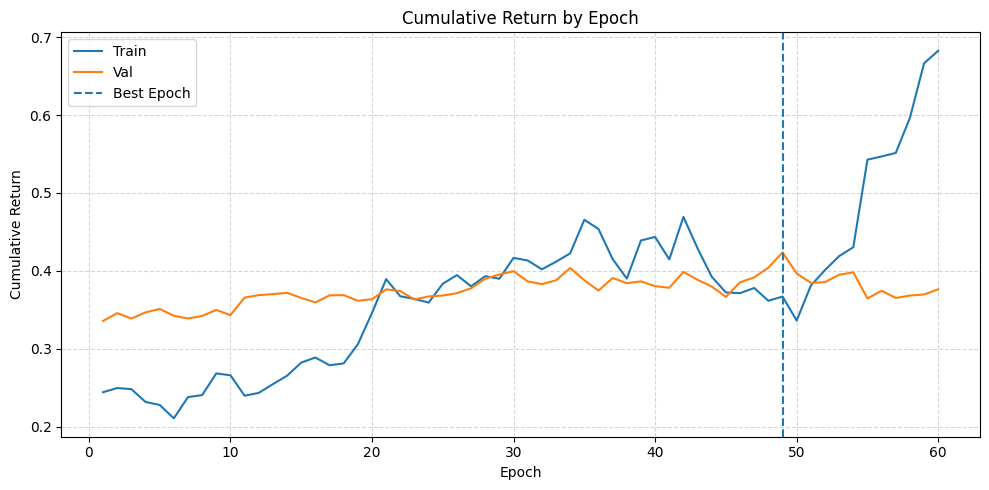

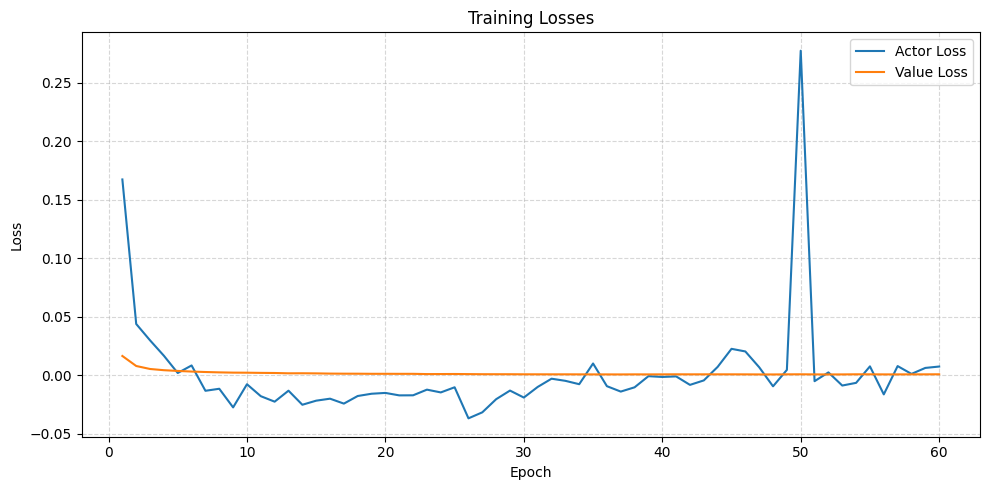

In [ ]:
# ============================================================
# CELL 18 — Plot training curves
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_cumulative_return"], label="Train")
plt.plot(history_df["epoch"], history_df["val_cumulative_return"], label="Val")
plt.axvline(best_epoch, linestyle="--", label="Best Epoch")
plt.title("Cumulative Return by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["actor_loss_mean"], label="Actor Loss")
plt.plot(history_df["epoch"], history_df["value_loss_mean"], label="Value Loss")
plt.title("Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

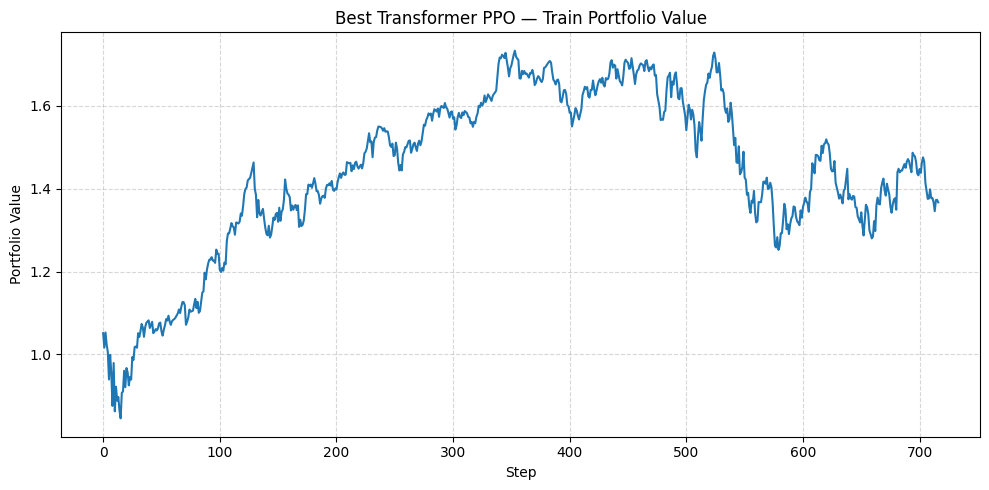

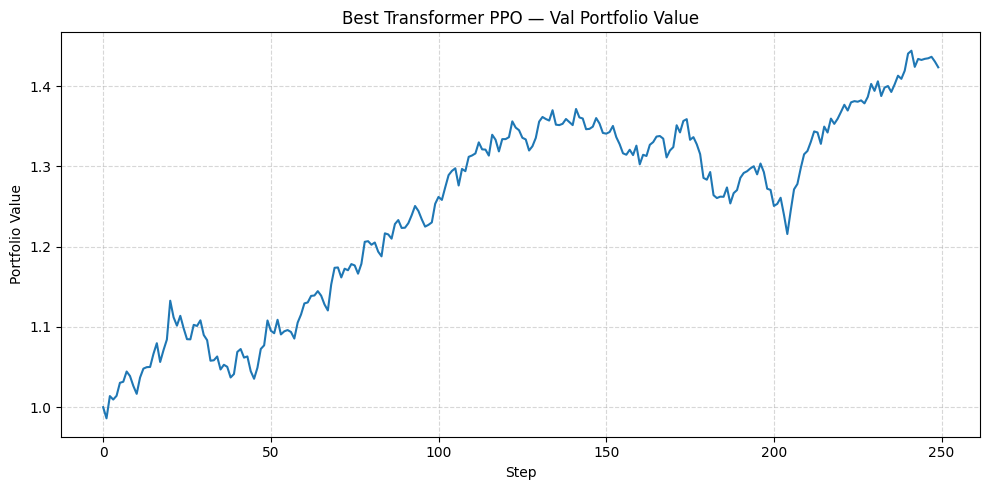

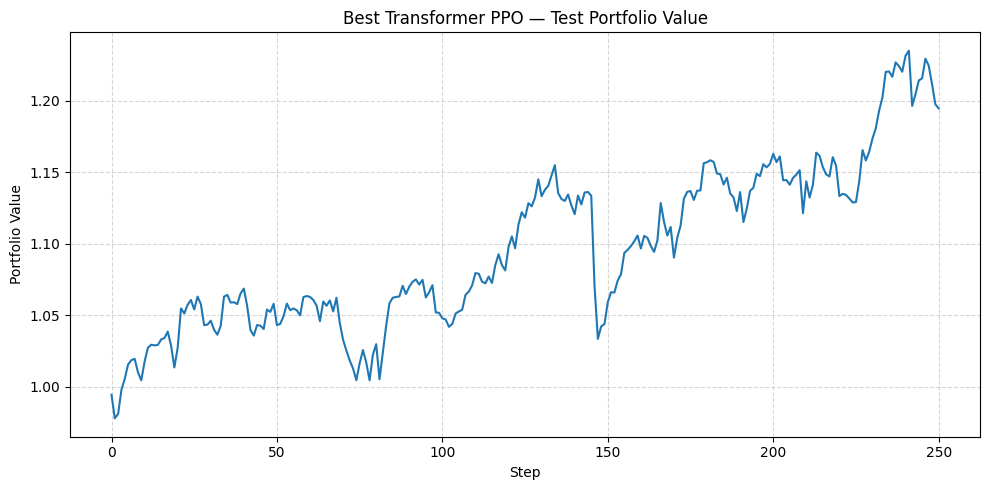

In [ ]:
# ============================================================
# CELL 19 — Plot best portfolio value curves
# ============================================================

def plot_rollout_pv(df_rollout: pd.DataFrame, title: str):
    plt.figure(figsize=(10, 5))
    plt.plot(df_rollout["portfolio_value"].values)
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Portfolio Value")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_rollout_pv(train_rollout_df, "Best Transformer PPO — Train Portfolio Value")
plot_rollout_pv(val_rollout_df, "Best Transformer PPO — Val Portfolio Value")
plot_rollout_pv(test_rollout_df, "Best Transformer PPO — Test Portfolio Value")

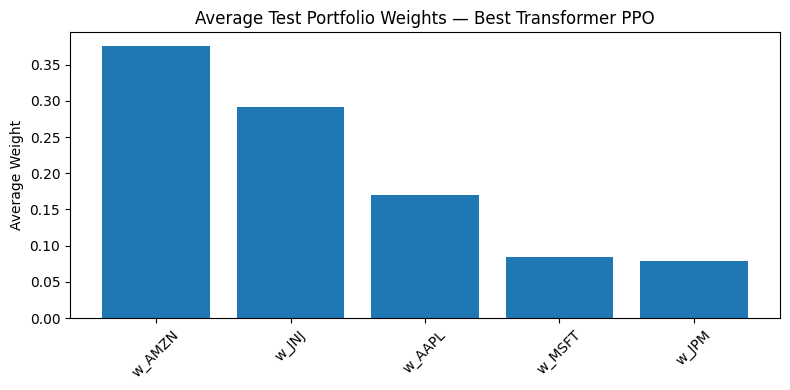

,avg_weight
w_AMZN,0.375767
w_JNJ,0.290890
w_AAPL,0.170605
w_MSFT,0.084288
w_JPM,0.078450


In [ ]:
# ============================================================
# CELL 20 — Plot average portfolio weights on test
# ============================================================

weight_cols = [f"w_{asset}" for asset in ASSETS]
avg_weights_test = test_rollout_df[weight_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(avg_weights_test.index, avg_weights_test.values)
plt.title("Average Test Portfolio Weights — Best Transformer PPO")
plt.ylabel("Average Weight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(avg_weights_test.to_frame("avg_weight"))

In [ ]:
# ============================================================
# CELL 21 — Save run config
# ============================================================

run_config = {
    "run_name": RUN_NAME,
    "seed": SEED,
    "device": DEVICE,
    "lookback": LOOKBACK,
    "n_assets": len(ASSETS),
    "n_features": len(FEATURE_COLS),
    "transaction_cost": TRANSACTION_COST,
    "d_model": D_MODEL,
    "nhead": NHEAD,
    "num_layers": NUM_LAYERS,
    "ff_dim": FF_DIM,
    "dropout": DROPOUT,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "gamma": GAMMA,
    "gae_lambda": GAE_LAMBDA,
    "clip_eps": CLIP_EPS,
    "value_coef": VALUE_COEF,
    "entropy_coef": ENTROPY_COEF,
    "max_grad_norm": MAX_GRAD_NORM,
    "train_epochs": TRAIN_EPOCHS,
    "ppo_updates_per_epoch": PPO_UPDATES_PER_EPOCH,
    "minibatch_size": MINIBATCH_SIZE,
    "dirichlet_conc_min": DIRICHLET_CONC_MIN,
    "dirichlet_conc_max": DIRICHLET_CONC_MAX,
    "best_epoch": int(best_epoch),
    "best_val_cumulative_return": float(best_val_cumret),
}

with open(f"{MODEL_DIR}/run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

print("Saved:", f"{MODEL_DIR}/run_config.json")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y/run_config.json


In [ ]:
# ============================================================
# CELL 22 — Final sanity checks
# ============================================================

assert os.path.exists(f"{MODEL_DIR}/best_model.pt")
assert os.path.exists(f"{MODEL_DIR}/training_history.csv")
assert os.path.exists(f"{MODEL_DIR}/summary_metrics_best.csv")
assert os.path.exists(f"{MODEL_DIR}/run_config.json")

assert len(train_rollout_df) == len(X_train)
assert len(val_rollout_df) == len(X_val)
assert len(test_rollout_df) == len(X_test)

print("All Transformer PPO training notebook checks passed.")

All Transformer PPO training notebook checks passed.
